In [18]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
data = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data(data)

In [20]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

optimization = optuna.create_study(direction="minimize") #Finding the parameters that minimize the MAE
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-01-24 15:38:55,670] A new study created in memory with name: no-name-accddb44-3926-4e61-b711-5f63e13d9937
[I 2026-01-24 15:38:56,183] Trial 0 finished with value: 9758.342618624063 and parameters: {'learning_rate': 0.05015992948913901, 'max_depth': 2, 'subsample': 0.7248887052920138, 'colsample_bytree': 0.7540119318210339}. Best is trial 0 with value: 9758.342618624063.
[I 2026-01-24 15:38:56,802] Trial 1 finished with value: 9754.318871760324 and parameters: {'learning_rate': 0.03831127923635789, 'max_depth': 2, 'subsample': 0.8488138906236321, 'colsample_bytree': 0.7841995421630508}. Best is trial 1 with value: 9754.318871760324.
[I 2026-01-24 15:38:57,381] Trial 2 finished with value: 9609.28191536849 and parameters: {'learning_rate': 0.01472440154703193, 'max_depth': 2, 'subsample': 0.7567995578505552, 'colsample_bytree': 0.6775545617156411}. Best is trial 2 with value: 9609.28191536849.
[I 2026-01-24 15:38:58,213] Trial 3 finished with value: 6189.131330261694 and paramete

Optimal Parameters: {'learning_rate': 0.05889545551814155, 'max_depth': 5, 'subsample': 0.6723221663306375, 'colsample_bytree': 0.657628416447041}
XGBoost Error: 3387.319196675359
Mean XGBoost Error: 930.4642729574157


Sample0: True = 665.00s, Predicted = 746.81s, Error=81.81s
Sample1: True = 897.75s, Predicted = 766.69s, Error=131.06s
Sample2: True = 1377.25s, Predicted = 1152.26s, Error=224.99s
Sample3: True = 1545.00s, Predicted = 1004.65s, Error=540.35s
Sample4: True = 1230.00s, Predicted = 787.76s, Error=442.24s
Sample5: True = 803.75s, Predicted = 1013.31s, Error=209.56s
Sample6: True = 790.00s, Predicted = 1296.21s, Error=506.21s
Sample7: True = 1196.25s, Predicted = 1245.08s, Error=48.83s
Sample8: True = 920.00s, Predicted = 847.23s, Error=72.77s
Sample9: True = 715.00s, Predicted = 870.62s, Error=155.62s
Sample10: True = 1223.75s, Predicted = 995.03s, Error=228.72s
Sample11: True = 1396.25s, Predicted = 1007.70s, Error=388.55s
Sample12: True = 1448.75s, Predicted = 1176.20s, Error=272.55s
Sample13: True = 1446.25s, Predicted = 780.43s, Error=665.82s
Sample14: True = 1505.00s, Predicted = 1194.26s, Error=310.74s
Sample15: True = 615.00s, Predicted = 860.53s, Error=245.53s
Sample16: True = 868

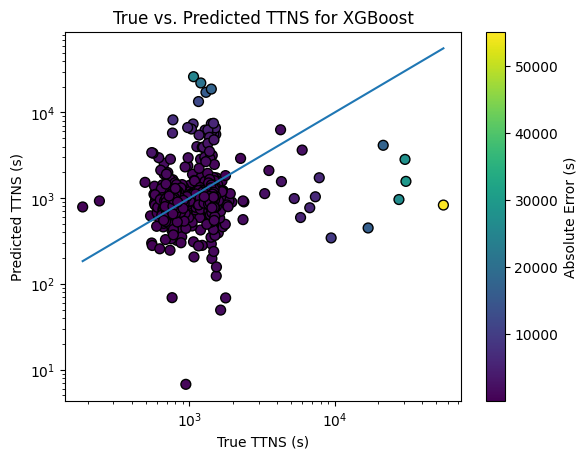

In [21]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction

absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
plt.xscale('log')
plt.yscale('log')
plt.show()

 96%|=================== | 739/773 [00:18<00:00]       

XG Boost Drivers: time_since     385.999219
form_fac       230.586503
tide_deriv     210.266417
slip_size      204.958186
tide_height    190.375046
high_t_evt      33.926827
dtype: float64


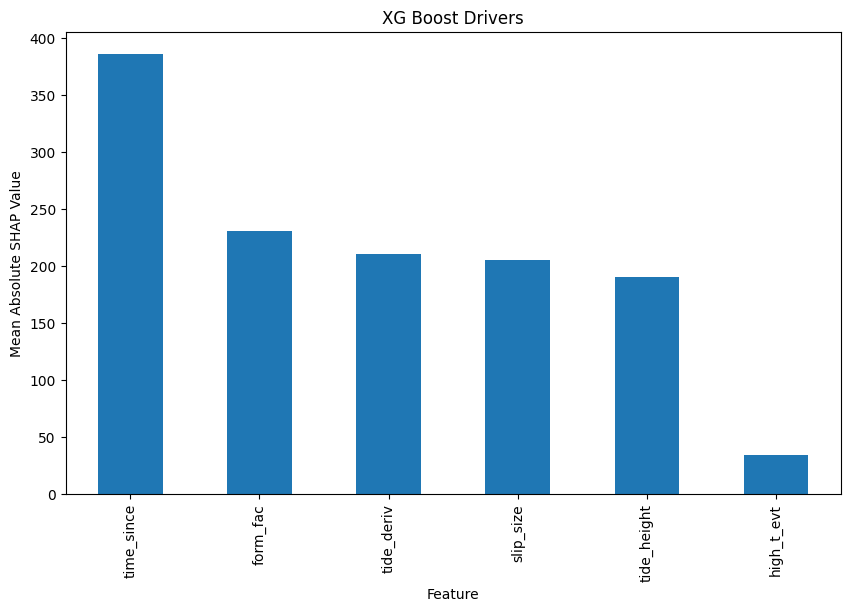

In [22]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()
